In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/nihal_farooq_m/Bro_Files/Week 15/Datasets/mess_gemini.csv')
df

,Transaction_ID,Gender,Income,Age,Join_Date,Department,Product_Rating,Sales_Amount
0,ID_1,Male,55000.50,34.0,2020-03-23,Sales,4/5 stars,2300.1
1,ID_2,female,"$62,000",28.0,15/04/2021,Engineering,5,4000.0
2,ID_3,F,NaN,500.0,Unknown,HR,3.5,1200.5
3,ID_4,M,48000.00,-5.0,2020-11-01,Marketing,2/5 stars,1500.2
4,ID_5,Male,120000.00,45.0,2021-01-10,Sales,4,3000.0
5,ID_6,woman,55000.00,34.0,2020-03-23,Support,Not Rated,800.0
6,ID_7,Fem,95000,52.0,2019-05-15,Engineering,5 stars,5000.0
7,ID_8,Male,72000.00,NaN,01/02/2022,Marketing,3,2100.0
8,ID_9,M,"$10,500,000",31.0,2020-08-20,Sales,1,200.0
9,ID_10,Male,49000,29.0,Unknown,HR,4.2,1800.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  32 non-null     object 
 1   Gender          32 non-null     object 
 2   Income          28 non-null     object 
 3   Age             30 non-null     float64
 4   Join_Date       31 non-null     object 
 5   Department      32 non-null     object 
 6   Product_Rating  29 non-null     object 
 7   Sales_Amount    32 non-null     float64
dtypes: float64(2), object(6)
memory usage: 2.1+ KB


In [4]:
df.describe()

,Age,Sales_Amount
count,30.000000,32.000000
mean,57.133333,2228.196875
std,91.012971,1228.906921
min,-5.000000,200.000000
25%,28.250000,1275.125000
50%,34.000000,2300.100000
75%,40.750000,3025.000000
max,500.000000,5000.000000


In [5]:
null_num = df.isna().sum().sort_values()
print(null_num / len(df) * 100, null_num)

Transaction_ID     0.000
Gender             0.000
Department         0.000
Sales_Amount       0.000
Join_Date          3.125
Age                6.250
Product_Rating     9.375
Income            12.500
dtype: float64 Transaction_ID    0
Gender            0
Department        0
Sales_Amount      0
Join_Date         1
Age               2
Product_Rating    3
Income            4
dtype: int64


In [6]:
num_col = df.select_dtypes(include = 'number').columns
num_col

Index(['Age', 'Sales_Amount'], dtype='object')

In [7]:
cat_col = df.select_dtypes(include = 'object').columns
cat_col

Index(['Transaction_ID', 'Gender', 'Income', 'Join_Date', 'Department',
       'Product_Rating'],
      dtype='object')

In [25]:
df['Income'] = df['Income'].str.replace(r'[$,]', '', regex = True)
df

,Transaction_ID,Gender,Income,Age,Join_Date,Department,Product_Rating,Sales_Amount
0,ID_1,M,55000.50,34.0,2020-03-23,Sales,4,2300.1
1,ID_2,F,62000,28.0,15/04/2021,Engineering,5,4000.0
2,ID_3,F,NaN,500.0,Unknown,HR,3.5,1200.5
3,ID_4,M,48000.00,-5.0,2020-11-01,Marketing,2/5 stars,1500.2
4,ID_5,M,120000.00,45.0,2021-01-10,Sales,4,3000.0
5,ID_6,F,55000.00,34.0,2020-03-23,Support,Not Rated,800.0
6,ID_7,M,95000,52.0,2019-05-15,Engineering,5 stars,5000.0
7,ID_8,M,72000.00,NaN,01/02/2022,Marketing,3,2100.0
8,ID_9,M,10500000,31.0,2020-08-20,Sales,1,200.0
9,ID_10,M,49000,29.0,Unknown,HR,4.2,1800.5


In [10]:
for i in range(len(df)):
    if df['Gender'][i] in ['Female', 'female', 'fem', 'woman', 'f']:
        df['Gender'][i] = 'F'
df

/tmp/ipykernel_6473/1292199191.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Gender'][i] = 'F'
/tmp/ipykernel_6473/1292199191.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the

,Transaction_ID,Gender,Income,Age,Join_Date,Department,Product_Rating,Sales_Amount
0,ID_1,Male,55000.50,34.0,2020-03-23,Sales,4/5 stars,2300.1
1,ID_2,F,"62,000",28.0,15/04/2021,Engineering,5,4000.0
2,ID_3,F,NaN,500.0,Unknown,HR,3.5,1200.5
3,ID_4,M,48000.00,-5.0,2020-11-01,Marketing,2/5 stars,1500.2
4,ID_5,Male,120000.00,45.0,2021-01-10,Sales,4,3000.0
5,ID_6,F,55000.00,34.0,2020-03-23,Support,Not Rated,800.0
6,ID_7,Fem,95000,52.0,2019-05-15,Engineering,5 stars,5000.0
7,ID_8,Male,72000.00,NaN,01/02/2022,Marketing,3,2100.0
8,ID_9,M,"10,500,000",31.0,2020-08-20,Sales,1,200.0
9,ID_10,Male,49000,29.0,Unknown,HR,4.2,1800.5


In [11]:
for i in range(len(df)):
    if df['Gender'][i] != 'F':
        df['Gender'][i] = 'M'
df

/tmp/ipykernel_6473/467414936.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Gender'][i] = 'M'
/tmp/ipykernel_6473/467414936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the c

,Transaction_ID,Gender,Income,Age,Join_Date,Department,Product_Rating,Sales_Amount
0,ID_1,M,55000.50,34.0,2020-03-23,Sales,4/5 stars,2300.1
1,ID_2,F,"62,000",28.0,15/04/2021,Engineering,5,4000.0
2,ID_3,F,NaN,500.0,Unknown,HR,3.5,1200.5
3,ID_4,M,48000.00,-5.0,2020-11-01,Marketing,2/5 stars,1500.2
4,ID_5,M,120000.00,45.0,2021-01-10,Sales,4,3000.0
5,ID_6,F,55000.00,34.0,2020-03-23,Support,Not Rated,800.0
6,ID_7,M,95000,52.0,2019-05-15,Engineering,5 stars,5000.0
7,ID_8,M,72000.00,NaN,01/02/2022,Marketing,3,2100.0
8,ID_9,M,"10,500,000",31.0,2020-08-20,Sales,1,200.0
9,ID_10,M,49000,29.0,Unknown,HR,4.2,1800.5


In [16]:
for i in range(len(df)):
    st = df['Product_Rating'][i].split(r'[/ ]')
    print(st)
df

['4']
['5']
['3.5']
['2/5 stars']
['4']
['Not Rated']
['5 stars']
['3']
['1']
['4.2']
['4/5 stars']
['3/5']


AttributeError: 'float' object has no attribute 'split'

In [18]:
df

,Transaction_ID,Gender,Income,Age,Join_Date,Department,Product_Rating,Sales_Amount
0,ID_1,M,55000.50,34.0,2020-03-23,Sales,4,2300.1
1,ID_2,F,"62,000",28.0,15/04/2021,Engineering,5,4000.0
2,ID_3,F,NaN,500.0,Unknown,HR,3.5,1200.5
3,ID_4,M,48000.00,-5.0,2020-11-01,Marketing,2/5 stars,1500.2
4,ID_5,M,120000.00,45.0,2021-01-10,Sales,4,3000.0
5,ID_6,F,55000.00,34.0,2020-03-23,Support,Not Rated,800.0
6,ID_7,M,95000,52.0,2019-05-15,Engineering,5 stars,5000.0
7,ID_8,M,72000.00,NaN,01/02/2022,Marketing,3,2100.0
8,ID_9,M,"10,500,000",31.0,2020-08-20,Sales,1,200.0
9,ID_10,M,49000,29.0,Unknown,HR,4.2,1800.5


In [27]:
df.Income = df.Income.astype(float)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  32 non-null     object 
 1   Gender          32 non-null     object 
 2   Income          28 non-null     float64
 3   Age             30 non-null     float64
 4   Join_Date       31 non-null     object 
 5   Department      32 non-null     object 
 6   Product_Rating  29 non-null     object 
 7   Sales_Amount    32 non-null     float64
dtypes: float64(3), object(5)
memory usage: 2.1+ KB


<Axes: ylabel='Income'>

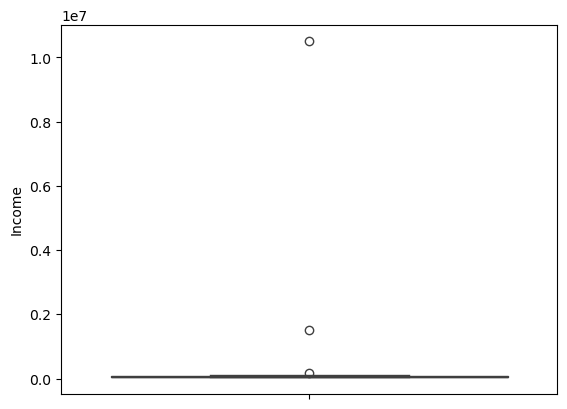

In [28]:
sns.boxplot(data = df.Income)

<Axes: xlabel='Income', ylabel='Count'>

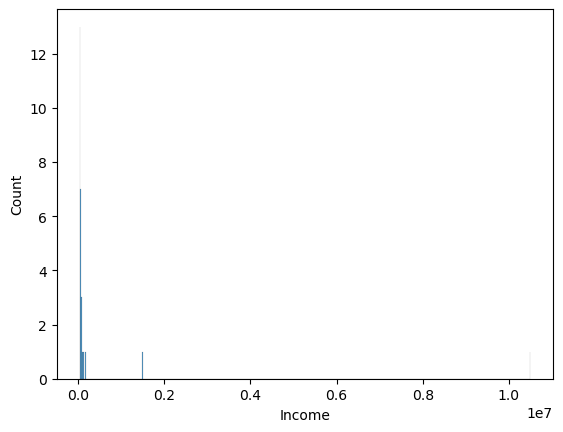

In [30]:
sns.histplot(data = df.Income)

In [ ]:
df.Income.fillna(df.Inmcome.mean())
df